<div align="center">
  <h1 style="color:#FFB347;">🚀 JV Food</h1>
  <h3 style="color:#aaa; font-weight:normal;"><i>Exploratory analysis & A/B testing on in-app user behavior</i></h3>
  <hr style="border: 1px solid #FFB347; width:50%;">
</div>

## 📚 Import libraries.

In [1]:
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys as st
import seaborn as sns
import scipy
from scipy import stats
import statsmodels.stats.proportion
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

In [2]:
# Create a file including requirements.
!pip freeze > requirements.txt
print("Done! Check requirements.txt")

Done! Check requirements.txt


## 📝 Project description.

JV Food is a food products company. This analysis focuses on understanding user behavior within the app. <br>  
### 🧹Data Cleaning.
The first step is cleaning the data by applying the actions below in order to **get cleaner information** to make the analysis easier. <br>
• Snake case to the dataset's columns. <br>
• Check datatypes. <br>
• Check absent values. <br>
• Edit data if necesary. <br>
### 📊 Exploratory Analysis.
Once we have obtained clean information, we will start the next step computing the following metrics: <br>
• Total events quantity. <br>
• Total users quantity. <br>
• Average events per user. <br>
• What time period does the data cover? <br>
### 🔽 Funnel Analysis.
The next part of the project includes the event funnel analysis, where we will find: <br> 
• Event frequency and order. <br> 
• Drop-off rates per stage. <br>
• Payment completion rate. <br> 
### ⚖️ Test A / A/ B.
Now it is time to analyze the experiment's results and we will find the points below: <br>

• Total users per group. <br>

• Verify statistical equivalence between both control groups. <br>
• Most popular event. <br>

## 📊 Data Loading.

In [3]:
# Create a DF.
df = pd.read_csv("logs_exp_us.csv", sep='\t')

In [4]:
# Show DF's head.
df.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


## 🧹Data Cleaning.

### Rename columns.

In [5]:
df.columns = df.columns.str.upper()
df.columns = ['event_name', 'user_id', 'event_ts', 'group_id']

### Data types.

In [6]:
# Show datatypes.
df.dtypes

event_name    object
user_id        int64
event_ts       int64
group_id       int64
dtype: object

In [7]:
# Convert column 'event_ts' to datetime.
df['event_ts'] = df['event_ts'].apply(lambda x: datetime.datetime.fromtimestamp(x))
# Verify the changes.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   event_name  244126 non-null  object        
 1   user_id     244126 non-null  int64         
 2   event_ts    244126 non-null  datetime64[ns]
 3   group_id    244126 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 7.5+ MB


In [8]:
# Create a column including the time of the record.
df['event_time'] = df['event_ts'].dt.time

In [9]:
# Check absent values.
print(f"Total absent values: {df.isna().sum().sum()}")

Total absent values: 0


### Duplicated values.

In [10]:
# Create a DF including duplicated values.
duplicates = df[df.duplicated(keep=False)]
print(f"Total duplicated values: {df.duplicated().sum()}")
print(f"Percentage of duplicated values taking as reference the total entries: {(len(duplicates)/len(df)) * 100:.2f} %")
print(duplicates.head())
# Calculate duplicated values per event.
duplicates_events = duplicates['event_name'].value_counts().reset_index()
duplicates_events.columns = ['event', 'frequency']
# Calculate duplicated values per group.
duplicates_group = duplicates['group_id'].value_counts().reset_index()
duplicates_group.columns = ['group', 'frequency']
duplicates_group['group'] = duplicates_group['group'].astype('object')

Total duplicated values: 413
Percentage of duplicated values taking as reference the total entries: 0.31 %
            event_name              user_id            event_ts  group_id  \
452   MainScreenAppear  5613408041324010552 2019-07-30 02:19:44       248   
453   MainScreenAppear  5613408041324010552 2019-07-30 02:19:44       248   
2348  CartScreenAppear  1694940645335807244 2019-07-31 15:51:39       248   
2350  CartScreenAppear  1694940645335807244 2019-07-31 15:51:39       248   
3572  MainScreenAppear   434103746454591587 2019-07-31 20:59:37       248   

     event_time  
452    02:19:44  
453    02:19:44  
2348   15:51:39  
2350   15:51:39  
3572   20:59:37  


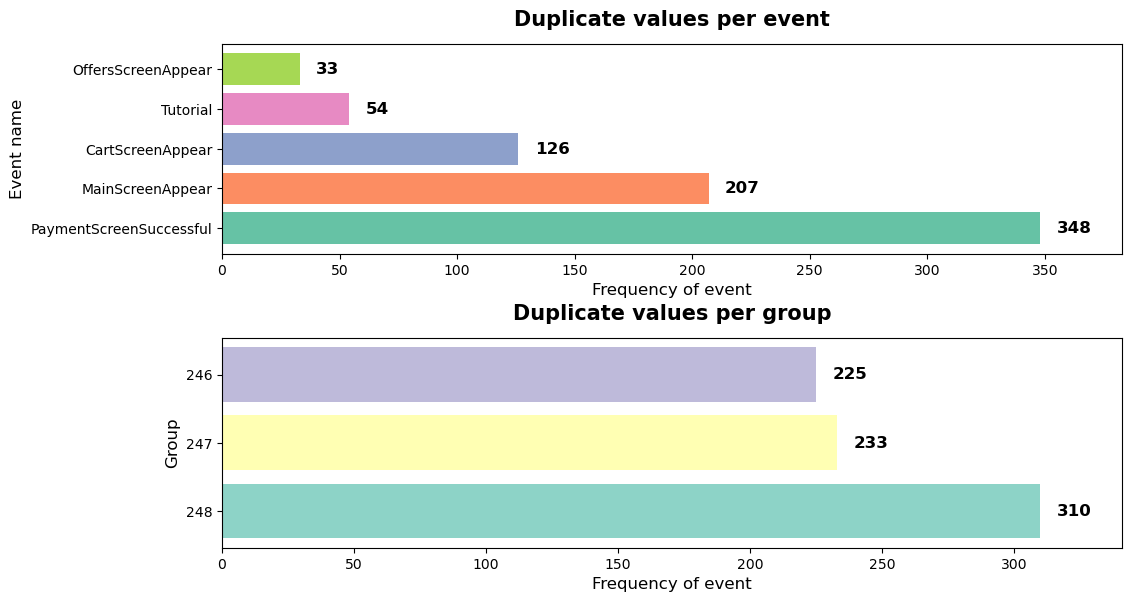

In [11]:

# Create graphics to show the information.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

# Graphic duplicates per events.
colors1 = plt.cm.Set2(range(len(duplicates_events)))
indices1 = range(len(duplicates_events))
ax1.barh(indices1, duplicates_events['frequency'], color=colors1)
offset1 = duplicates_events['frequency'].max() * 0.02
for i, freq1 in enumerate(duplicates_events['frequency']):
    ax1.text(freq1 + offset1, i, str(freq1), ha='left', va='center', fontsize=12, fontweight='bold', color='black')
ax1.set_yticks(indices1)
ax1.set_yticklabels(duplicates_events['event'])
ax1.set_xlim(0, duplicates_events['frequency'].max() * 1.1)
ax1.set_title("Duplicate values per event", fontweight='bold', fontsize=15, pad=13)
ax1.set_xlabel('Frequency of event', fontsize=12)
ax1.set_ylabel('Event name', fontsize=12)

# Graphic duplicates per group.
colors2 = plt.cm.Set3(range(len(duplicates_group)))
indices2 = range(len(duplicates_group))
ax2.barh(indices2, duplicates_group['frequency'], color=colors2)
offset2 = duplicates_group['frequency'].max() * 0.02
for i, freq2 in enumerate(duplicates_group['frequency']):
    ax2.text(freq2 + offset2, i, str(freq2), ha='left', va='center', fontsize=12, fontweight='bold', color='black')
ax2.set_yticks(indices2)
ax2.set_yticklabels(duplicates_group['group'])
ax2.set_xlim(0, duplicates_group['frequency'].max() * 1.1)
ax2.set_title("Duplicate values per group", fontweight='bold', fontsize=15, pad=13)
ax2.set_xlabel('Frequency of event', fontsize=12)
ax2.set_ylabel('Group', fontsize=12)

plt.subplots_adjust(left=0.2, right=0.95, top=0.95, hspace=0.4)
plt.show()


The DataFrame contains **413 duplicated values** analyzed from two perspectives.

**By event:** The most affected is *PaymentScreenSuccessful* with **348 duplicates**,
which could impact conversion and payment metrics. The remaining events show 
lower frequencies but would still affect the funnel analysis.

**By group:** 
- **Control groups** (246 & 247) show only an 8-duplicate delta **(225 vs 233)**,
so the distribution between them is pretty balanced.
- **Treatment group** (248) has the most duplicates with **310**.

Either way, duplicates only represent **0.3%** of **244,126 total entries**,
so **removing them won't significantly impact the analysis**.

In [12]:
df.drop_duplicates(inplace=True)

## 📊 Exploratory Analysis.

### Events list.

In [13]:
print(df['event_name'].unique())

['MainScreenAppear' 'PaymentScreenSuccessful' 'CartScreenAppear'
 'OffersScreenAppear' 'Tutorial']


The events included in the DataFrame are:

• Main screen appear.

• Tutorial.

• Offer screen appear.

• Cart screen appear.

• Payment screen successful.

The DataFrame contains **5 unique events**, each representing a step 
in the user's journey within the app.

### Users Quantity.

In [14]:
# Show the total of users.
print(df['user_id'].nunique())

7551


The DataFrame includes **7,551 users** shown in the column **user_id**. 

### Average events per user.

In [15]:
# Create a DF including total events per user.
events_per_user = df.groupby(['user_id']).agg({'event_name':'count'}).reset_index()
# Rename the columns.
events_per_user.columns = ['user', 'total_events']
# Calculate the average.
avg_events_per_user = events_per_user['total_events'].mean()
# Show the information.
print(f"Average total events per user is: {avg_events_per_user:.2f}")
percentiles = np.percentile(events_per_user['total_events'], [25, 50, 75, 95, 99])
percentiles

Average total events per user is: 32.28


array([  9. ,  20. ,  37. ,  89. , 200.5])

The average number of events per user is **32.28**.

Looking at the distribution:

* **25%** of users trigger **9 or fewer** events.

* **50%** of users trigger **20 or fewer** events.

* **75%** of users trigger **37 or fewer** events.

* **95%** of users trigger **89 or fewer** events.

* **99%** of users trigger **200 or fewer** events.

The gap between the 75th and 99th percentile suggests the presence of 
**power users** who interact significantly more with the app than the average user.

### Time period.

In [16]:
# Calculate the maximum date.
max_date = df['event_ts'].max()
print(max_date)
# Calculate the minimum date.
min_date = df['event_ts'].min()
print(min_date)
# Calculate the period.
period = pd.to_timedelta(df['event_ts'].dt.date.max() - df['event_ts'].dt.date.min(), unit='d')
print(period)

2019-08-07 15:15:17
2019-07-24 22:43:36
14 days 00:00:00


The dataset includes data from a 13-day period, starting on July 25th, 2019 until August 7th, 2019.

### Date / Time Distribution.

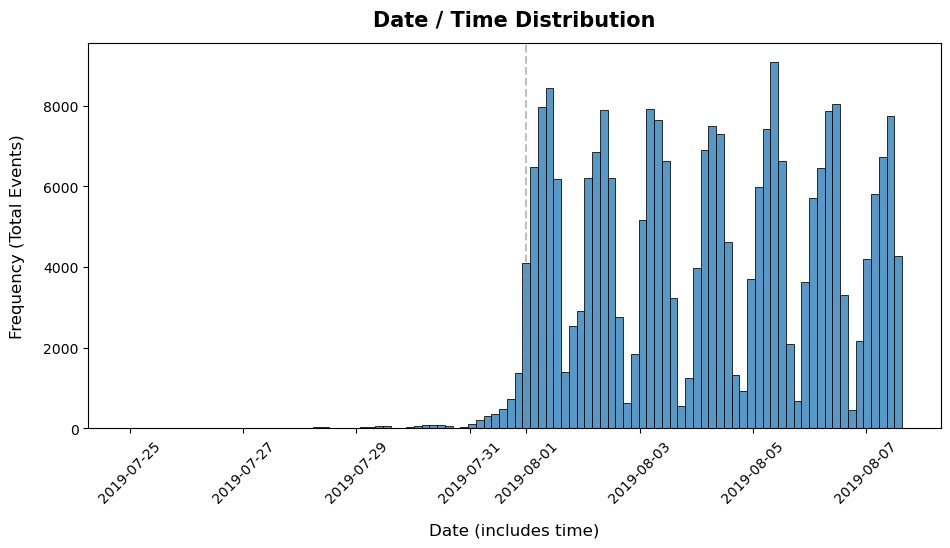

In [17]:
# Create a graphic to show the date/time distribution.
fig, ax = plt.subplots(figsize=(11, 5))
dates = sns.histplot(
    data=df['event_ts'],
    bins=100
)
ax.axvline(x=pd.to_datetime('2019-08-01'), linestyle='--', color='grey', alpha=0.5)
plt.title('Date / Time Distribution', fontweight='bold', fontsize=15, pad=13)
plt.xlabel('Date (includes time)', fontsize=12, labelpad=13)
plt.ylabel('Frequency (Total Events)', fontsize=12, labelpad=13)
plt.xticks(rotation=45)
plt.show()

In [18]:
# Filter orginal DF.
df_clean = df[df['event_ts'] >= (pd.to_datetime('2019-08-01'))]
# Calculate total entries.
total_entries = len(df['event_name'])
# Calculate total entries after removing data.
entries_filtered = len(df_clean['event_name'])
# Calculate the gap.
gap_entries = total_entries - entries_filtered
# Calculate the percentage.
percentage_entries = (entries_filtered / total_entries)
# Calculate total users.
total_users = df['user_id'].nunique()
# Calculate total users after removing data.
users_filtered = df_clean['user_id'].nunique()
# Calculate the gap.
gap_users = total_users - users_filtered
# Calculate the percentage users.
percentage_users = (users_filtered / total_users)
# Show the results.
print(f"Total entries: {total_entries}")
print(f"Total entries filtered: {entries_filtered}")
print(f"Gap between total entries and total entries filtered: {gap_entries}")
print(f"Percentage of the data removed: {percentage_entries:.2f}%")
print(f"Total users: {total_users}")
print(f"Total users filtered: {users_filtered}")
print(f"Gap between total users and total users filtered: {gap_users}")
print(f"Percentage of the total users: {percentage_users:.3f}%")

Total entries: 243713
Total entries filtered: 237531
Gap between total entries and total entries filtered: 6182
Percentage of the data removed: 0.97%
Total users: 7551
Total users filtered: 7516
Gap between total users and total users filtered: 35
Percentage of the total users: 0.995%


This graphic shows an events behavior including **date and time**, that's why we can notice **some peaks**. It also reflects a change from **August 1st** due to an event's frequency increase reaching more than **8,000 events**.

Due to the **large gap** observed from **August 1st, we will remove** all records earlier than this date in order to get a **cleaner analysis.**
The total entries is: **243,713 entries** and after removing entries **earlier than August 1st** the total is: **240,887 entries**. The result is: **2,826 entries removed**. It corresponds to **0.99% of the total entries**.

After removing the data, it is also worth noting: 

•**Total Users before removing**: 7,551 users.

•**Total Users after removing**: 7,534 users.

### (Events per group) Comparison before and after removing duplicated values.

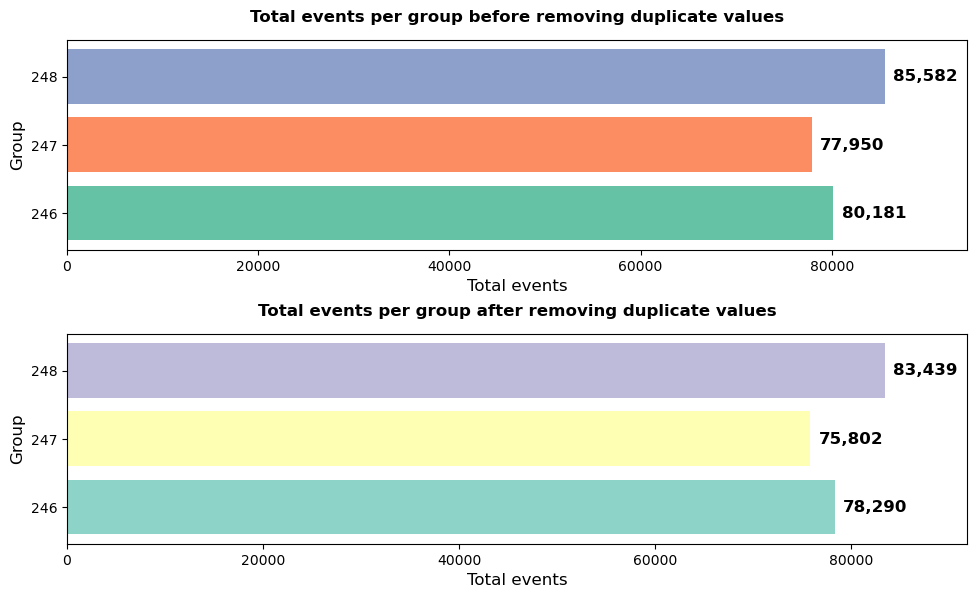

In [19]:
# Calculate total users per group before removing data.
total_events_per_group = df['group_id'].value_counts().sort_index(ascending=True).reset_index()
# Rename the columns.
total_events_per_group.columns = ['group', 'total_events']
# Calculate total users per group after removing data.
total_events_per_group_clean = df_clean['group_id'].value_counts().sort_index(ascending=True).reset_index()
# Rename the columns.
total_events_per_group_clean.columns = ['group', 'total_events']
# Create graphics to show the information.
fig, (ax3, ax4) = plt.subplots(2, 1, figsize=(12, 6))

# Graphic total users per group before removing duplicated values.
colors3 = plt.cm.Set2(range(len(total_events_per_group)))
indices3 = range(len(total_events_per_group))
ax3.barh(indices3, total_events_per_group['total_events'], color=colors3)
offset3 = total_events_per_group['total_events'].max() * 0.01
for i, freq3 in enumerate(total_events_per_group['total_events']):
    ax3.text(freq3 + offset3, i, f'{freq3:,}', ha='left', va='center', fontsize=12, fontweight='bold', color='black')
ax3.set_yticks(indices3)
ax3.set_yticklabels(total_events_per_group['group'])
ax3.set_xlim(0, total_events_per_group['total_events'].max() * 1.1)
ax3.set_title("Total events per group before removing duplicate values", fontweight='bold', fontsize=12, pad=13)
ax3.set_xlabel('Total events', fontsize=12)
ax3.set_ylabel('Group', fontsize=12)

# Graphic total users per group before removing duplicated values.
colors4 = plt.cm.Set3(range(len(total_events_per_group_clean)))
indices4 = range(len(total_events_per_group_clean))
ax4.barh(indices4, total_events_per_group_clean['total_events'], color=colors4)
offset4 = total_events_per_group_clean['total_events'].max() * 0.01
for i, freq4 in enumerate(total_events_per_group_clean['total_events']):
    ax4.text(freq4 + offset4, i, f'{freq4:,}', ha='left', va='center', fontsize=12, fontweight='bold', color='black')
ax4.set_yticks(indices4)
ax4.set_yticklabels(total_events_per_group_clean['group'])
ax4.set_xlim(0, total_events_per_group_clean['total_events'].max() * 1.1)
ax4.set_title("Total events per group after removing duplicate values", fontweight='bold', fontsize=12, pad=13)
ax4.set_xlabel('Total events', fontsize=12)
ax4.set_ylabel('Group', fontsize=12)

plt.subplots_adjust(left=0.2, right=0.95, top=0.95, hspace=0.4)
plt.show()

The difference between the **quantity of events per group** by removing duplicate values represents about **1.2% removed for each one**, which means that this change **does not affect the analysis**.

### (Users per group) Comparison before and after removing duplicated values.

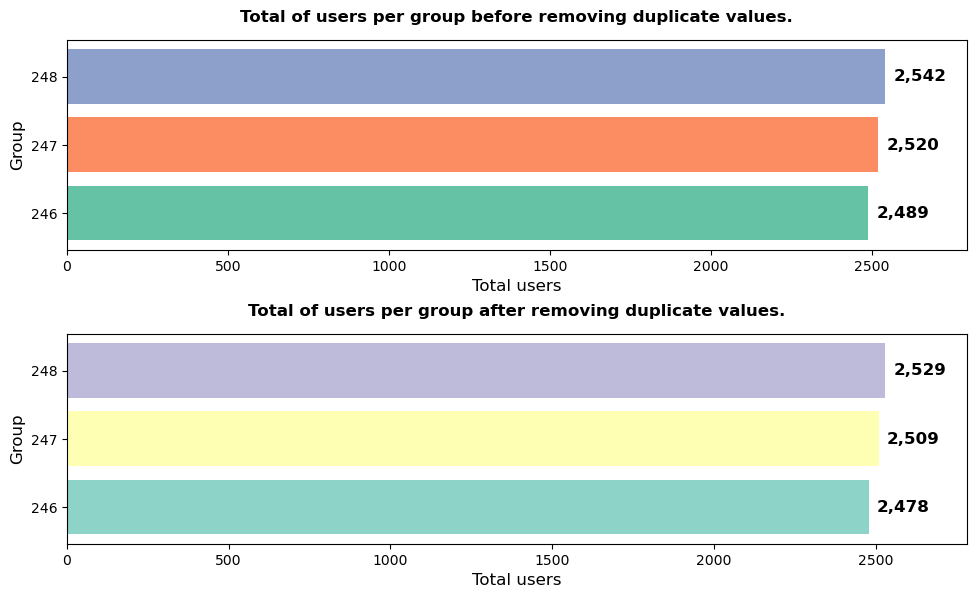

In [20]:
# Calculate total users before removing duplicate values.
users_per_group = df.groupby(['group_id']).agg({'user_id':'nunique'}).reset_index()
# Rename the columns.
users_per_group.columns = ['group', 'total_users']
# Sort values by group.
users_per_group.sort_values(by='group', ascending=True)
# Calculate total users after removing duplicate values.
users_per_group_clean = df_clean.groupby(['group_id']).agg({'user_id':'nunique'}).reset_index()
# Rename the columns.
users_per_group_clean.columns = ['group', 'total_users']
# Sort values by group.
users_per_group_clean.sort_values(by='group', ascending=True)
# Create graphics to compare the information.
fig, (ax5, ax6) = plt.subplots(2, 1, figsize=(12,6))
colors5 = plt.cm.Set2(range(len(users_per_group)))
indices5 = range(len(users_per_group))
ax5.barh(indices5, users_per_group['total_users'], color=colors5)
offset5 = users_per_group['total_users'].max() * 0.01
for i, freq5 in enumerate(users_per_group['total_users']):
    ax5.text(freq5 + offset5, i, f'{freq5:,}', ha='left', va='center', fontsize=12, fontweight='bold', color='black')
ax5.set_yticks(indices5)
ax5.set_yticklabels(users_per_group['group'])
ax5.set_xlim(0, users_per_group['total_users'].max() * 1.1)
ax5.set_title("Total of users per group before removing duplicate values.", fontweight='bold', fontsize=12, pad=13)
ax5.set_xlabel('Total users', fontsize=12)
ax5.set_ylabel('Group', fontsize=12)

colors6 = plt.cm.Set3(range(len(users_per_group_clean)))
indices6 = range(len(users_per_group_clean))
ax6.barh(indices6, users_per_group_clean['total_users'], color=colors6)
offset6 = users_per_group_clean['total_users'].max() * 0.01
for i, freq6 in enumerate(users_per_group_clean['total_users']):
    ax6.text(freq6 + offset6, i, f'{freq6:,}', ha='left', va='center', fontsize=12, fontweight='bold', color='black')
ax6.set_yticks(indices6)
ax6.set_yticklabels(users_per_group_clean['group'])
ax6.set_xlim(0, users_per_group_clean['total_users'].max() * 1.1)
ax6.set_title("Total of users per group after removing duplicate values.", fontweight='bold', fontsize=12, pad=13)
ax6.set_xlabel('Total users', fontsize=12)
ax6.set_ylabel('Group', fontsize=12)

plt.subplots_adjust(left=0.2, right=0.95, top=0.95, hspace=0.4)
plt.show()

The total of users after removing the duplicate values just **decreased about 0.2%**, which does not affect the analysis.

### Frequency of events.

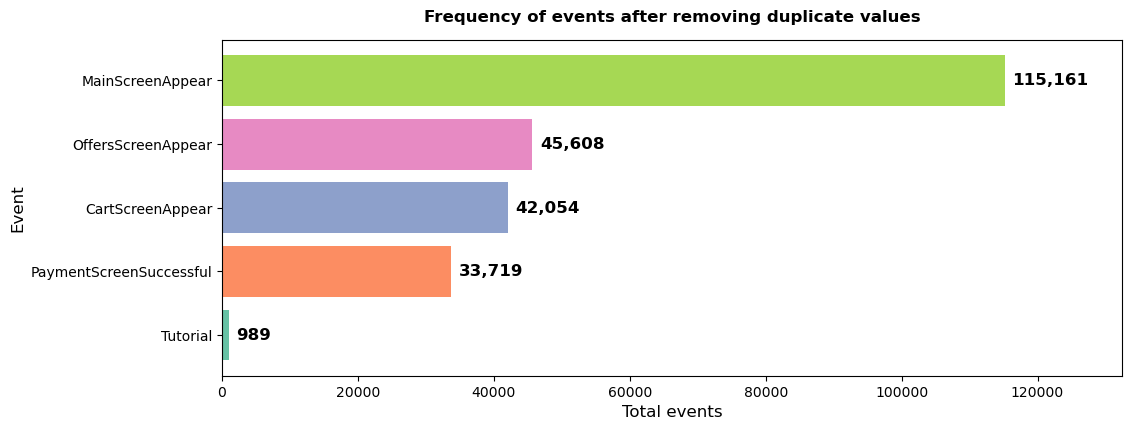

In [21]:
# Calculate frequency per events after removing data.
total_events_clean = df_clean['event_name'].value_counts().sort_values(ascending=True).reset_index()
# Rename the columns.
total_events_clean.columns = ['event', 'frequency']
# Create a graphic to show the information.
fig, ax7 = plt.subplots(figsize=(12,4))
colors7 = plt.cm.Set2(range(len(total_events_clean)))
indices7 = range(len(total_events_clean))
ax7.barh(indices7, total_events_clean['frequency'], color=colors7)
offset7 = total_events_clean['frequency'].max() * 0.01
for i, freq7 in enumerate(total_events_clean['frequency']):
    ax7.text(freq7 + offset7, i, f'{freq7:,}', ha='left', va='center', fontsize=12, fontweight='bold', color='black')
ax7.set_yticks(indices7)
ax7.set_yticklabels(total_events_clean['event'])
ax7.set_xlim(0, total_events_clean['frequency'].max() * 1.15)
ax7.set_title("Frequency of events after removing duplicate values", fontweight='bold', fontsize=12, pad=13)
ax7.set_xlabel('Total events', fontsize=12)
ax7.set_ylabel('Event', fontsize=12)

plt.subplots_adjust(left=0.2, right=0.95, top=0.95, hspace=0.4)
plt.show()

According to this graphic, we can determine the sequence that follows the trip on the website: 

• Main Screen Appear.

• Offers Screen Appear.

• Cart Screen Appear.

• Payment Screen Succesful.

The **Tutorial** event shows a significantly **lower frequency (1,005)** compared to the rest of the funnel steps, suggesting it is only triggered for first-time users. For this reason, it will be treated as an **optional stage** and excluded from the main funnel analysis.

### Total users per event.

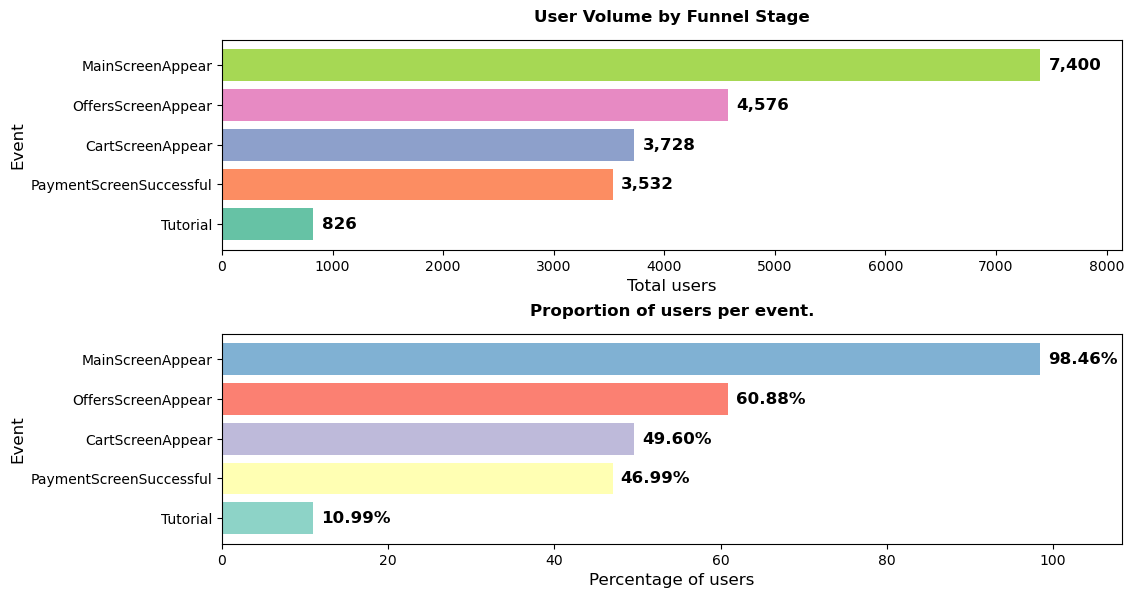

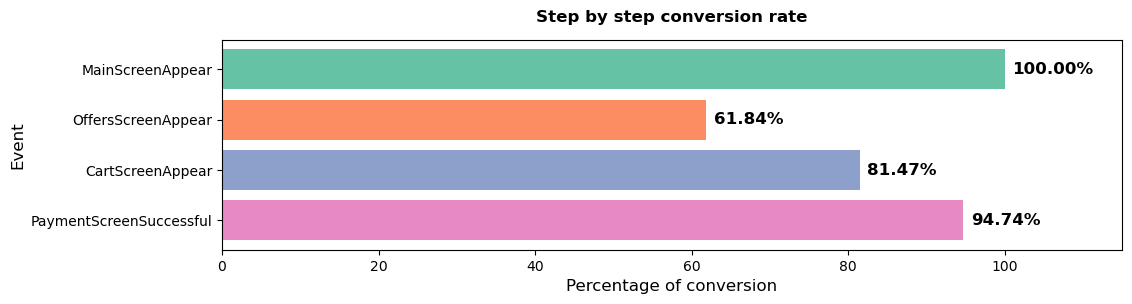

In [22]:
# Create a DF including users per event.
users_per_event = df_clean.groupby(['event_name']).agg({'user_id':'nunique'}).sort_values(by='user_id').reset_index()
# Rename the columns.
users_per_event.columns = ['event', 'total_users']
# Create a column calculating the proportion.
users_per_event['proportion'] = (users_per_event['total_users'] / (df_clean['user_id']).nunique()) * 100
# Create a DF sorting by 'proportion'.
funnel_proportion = users_per_event.sort_values(by='proportion', ascending=True)

fig, (ax8, ax9) = plt.subplots(2, 1, figsize=(12,6))
# Create a graphic to show the total users per event.
colors8 = plt.cm.Set2(range(len(users_per_event)))
indices8 = range(len(users_per_event))
ax8.barh(indices8, users_per_event['total_users'], color=colors8)
offset8 = users_per_event['total_users'].max() * 0.01
for i, freq8 in enumerate(users_per_event['total_users']):
    ax8.text(freq8 + offset8, i, f'{freq8:,}', ha='left', va='center', fontsize=12, fontweight='bold', color='black')
ax8.set_yticks(indices8)
ax8.set_yticklabels(users_per_event['event'])
ax8.set_xlim(0, users_per_event['total_users'].max() * 1.1)
ax8.set_title("User Volume by Funnel Stage", fontweight='bold', fontsize=12, pad=13)
ax8.set_xlabel('Total users', fontsize=12)
ax8.set_ylabel('Event', fontsize=12)
# Create a graphic to show the users proportion per event.
colors9 = plt.cm.Set3(range(len(funnel_proportion)))
indices9 = range(len(funnel_proportion))
ax9.barh(indices9, funnel_proportion['proportion'], color=colors9)
offset9 = funnel_proportion['proportion'].max() * 0.01
for i, freq9 in enumerate(funnel_proportion['proportion']):
    ax9.text(freq9 + offset9, i, f'{freq9:.2f}%', ha='left', va='center', fontsize=12, fontweight='bold', color='black')
ax9.set_yticks(indices9)
ax9.set_yticklabels(funnel_proportion['event'])
ax9.set_xlim(0, funnel_proportion['proportion'].max() * 1.1)
ax9.set_title("Proportion of users per event.", fontweight='bold', fontsize=12, pad=13)
ax9.set_xlabel('Percentage of users', fontsize=12)
ax9.set_ylabel('Event', fontsize=12)

plt.subplots_adjust(left=0.2, right=0.95, top=0.95, hspace=0.4)
plt.show()

# Create a DF by droping Tutorial.
funnel_order = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']
# Filter main DF.
users_per_event_ = (df_clean[df_clean['event_name'].isin(funnel_order)]
                   .groupby('event_name')['user_id']
                   .nunique()
                   .reindex(funnel_order)
                   .reset_index())
# Rename the columns.
users_per_event_.columns = ['event', 'total_users']
# Absolute conversion (vs first step).
users_per_event_['abs_conversion'] = (users_per_event_['total_users'] / 
                                      users_per_event_['total_users'].iloc[0] * 100)
# Step-by-step conversion (vs previous step).
users_per_event_['step_conversion'] = (users_per_event_['total_users'] / 
                                       users_per_event_['total_users'].shift(1) * 100).fillna(100)
# Create a graphic to show the information.
fig, ax10 = plt.subplots(figsize=(12,2.5))
colors10 = plt.cm.Set2(range(len(users_per_event_)))
indices10 = range(len(users_per_event_))
ax10.barh(indices10, users_per_event_['step_conversion'], color=colors10)
offset10 = users_per_event_['step_conversion'].max() * 0.01
for i, freq10 in enumerate(users_per_event_['step_conversion']):
    ax10.text(freq10 + offset10, i, f'{freq10:.2f}%', ha='left', va='center', fontsize=12, fontweight='bold', color='black')
ax10.invert_yaxis()
ax10.set_yticks(indices10)
ax10.set_yticklabels(users_per_event_['event'])
ax10.set_xlim(0, users_per_event_['step_conversion'].max() * 1.15)
ax10.set_title("Step by step conversion rate", fontweight='bold', fontsize=12, pad=13)
ax10.set_xlabel('Percentage of conversion', fontsize=12)
ax10.set_ylabel('Event', fontsize=12)

plt.subplots_adjust(left=0.2, right=0.95, top=0.95, hspace=0.4)
plt.show()

The **largest drop** in the funnel occurs **between MainScreenAppear and OffersScreenAppear**, where **38.1%** of users exit without exploring the offers. However, once users reach the Offers screen, the funnel becomes **highly efficient: 81.3%** proceed to the **Cart** and **94.8%** of those **complete the purchase**. This suggests the main friction point is early engagement, not the purchase flow itself.

## ⚖️ A/A/B Test.

### Volume users per group.

In [23]:
# Calculate total users for the two control groups.
users_246 = df_clean[df_clean['group_id'] == 246]['user_id'].nunique()
users_247 = df_clean[df_clean['group_id'] == 247]['user_id'].nunique()

total = users_246 + users_247

print(f"P-value: {proportions_ztest([users_246, users_247], [total, total])[1]:5f}")

P-value: 0.534726


According to the Z-test, we can see that **there is not** statistic difference between the **two control groups** and they are in balance.

### Top event per group.

We will create a **DataFrame for each group** in order to **identify the most popular event**. Additionally, the **user volume per event and its proportion** will be calculated and displayed.

In [24]:
# Create a DF for the first control group including the frequency per event.
top_246 = df_clean[df_clean['group_id'] == 246].value_counts(['event_name']).reset_index()
# Rename the columns.
top_246.columns = ['event_name', 'frequency']
# Create a DF for the first control group including the user volume per event.
users_top_246 = df_clean[df_clean['group_id'] == 246].groupby(['event_name']).agg({'user_id':'nunique'}).reset_index()
# Rename the columns.
users_top_246.columns = ['event_name', 'total_users']
# Join both DF.
top_246 = top_246.merge(users_top_246, on='event_name')
# Calculate the proportion per event.
top_246['proportion'] = (top_246['total_users'] / top_246.iloc[0][2]) * 100
# Show the DF.
top_246

C:\Users\franc\AppData\Local\Temp\ipykernel_17728\3976980116.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  top_246['proportion'] = (top_246['total_users'] / top_246.iloc[0][2]) * 100


,event_name,frequency,total_users,proportion
0,MainScreenAppear,37008,2444,100.000000
1,CartScreenAppear,14618,1265,51.759411
2,OffersScreenAppear,14564,1536,62.847791
3,PaymentScreenSuccessful,11788,1198,49.018003
4,Tutorial,312,274,11.211129


In [25]:
# Create a DF for the second control group including the frequency per event.
top_247 = df_clean[df_clean['group_id'] == 247].value_counts(['event_name']).reset_index()
# Rename the columns.
top_247.columns = ['event_name', 'frequency']
# Create a DF for the second control group including the user volume per event.
users_top_247 = df_clean[df_clean['group_id'] == 247].groupby(['event_name']).agg({'user_id':'nunique'}).reset_index()
# Rename the columns.
users_top_247.columns = ['event_name', 'total_users']
# Join both DF.
top_247 = top_247.merge(users_top_247, on='event_name')
# Calculate the proportion per event.
top_247['proportion'] = (top_247['total_users'] / top_247.iloc[0][2]) * 100
# Show the DF.
top_247

C:\Users\franc\AppData\Local\Temp\ipykernel_17728\180874165.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  top_247['proportion'] = (top_247['total_users'] / top_247.iloc[0][2]) * 100


,event_name,frequency,total_users,proportion
0,MainScreenAppear,38356,2472,100.000000
1,OffersScreenAppear,14891,1512,61.165049
2,CartScreenAppear,12328,1235,49.959547
3,PaymentScreenSuccessful,9896,1155,46.723301
4,Tutorial,331,276,11.165049


In [26]:
# Create a DF for the treatment group including the frequency per event.
top_248 = df_clean[df_clean['group_id'] == 248].value_counts(['event_name']).reset_index()
# Rename the columns.
top_248.columns = ['event_name', 'frequency']
# Create a DF for the first control group including the user volume per event.
users_top_248 = df_clean[df_clean['group_id'] == 248].groupby(['event_name']).agg({'user_id':'nunique'}).reset_index()
# Rename the columns.
users_top_248.columns = ['event_name', 'total_users']
# Join both DF.
top_248 = top_248.merge(users_top_248, on='event_name')
# Calculate the proportion per event.
top_248['proportion'] = (top_248['total_users'] / top_248.iloc[0][2]) * 100
# Show the DF.
top_248

C:\Users\franc\AppData\Local\Temp\ipykernel_17728\1880219087.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  top_248['proportion'] = (top_248['total_users'] / top_248.iloc[0][2]) * 100


,event_name,frequency,total_users,proportion
0,MainScreenAppear,39797,2484,100.000000
1,OffersScreenAppear,16153,1528,61.513688
2,CartScreenAppear,15108,1228,49.436393
3,PaymentScreenSuccessful,12035,1179,47.463768
4,Tutorial,346,276,11.111111


### Control groups combined.

As part of the analysis, we filtered the main DF obtaining a new one called **'Control groups'** that includes the information of **events frequency** and **user volume** for **both control groups**.

In [27]:
# Create a DF by calculating the frequency per event for both control groups.
control_groups = df_clean[(df_clean['group_id'] == 246) | (df_clean['group_id'] == 247)].value_counts(['event_name']).reset_index()
# Rename the columns.
control_groups.columns = ['event_name', 'frequency']
# Create a DF by calculating the user volume for both control groups
users_control_groups = df_clean[(df_clean['group_id'] == 246) | (df_clean['group_id'] == 247)].groupby(['event_name']).agg({'user_id':'nunique'}).reset_index()
# Rename the columns.
users_control_groups.columns = ['event_name', 'total_users']
# Join both DF.
control_groups = control_groups.merge(users_control_groups, on='event_name')
# Calculate the proportion per event.
control_groups['proportion'] = (control_groups['total_users'] / control_groups.iloc[0][2]) * 100
# Show the DF.
control_groups

C:\Users\franc\AppData\Local\Temp\ipykernel_17728\862733831.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  control_groups['proportion'] = (control_groups['total_users'] / control_groups.iloc[0][2]) * 100


,event_name,frequency,total_users,proportion
0,MainScreenAppear,75364,4916,100.000000
1,OffersScreenAppear,29455,3048,62.001627
2,CartScreenAppear,26946,2500,50.854353
3,PaymentScreenSuccessful,21684,2353,47.864117
4,Tutorial,643,550,11.187958


### Statistical tests.

We created a **function** in order to do a **statistical test** taking as **null hypothesis** the next one:

"The **user volume** beween both DF is **the same.**"

In [28]:
def ztest_event(event_name, df_1, df_2, alpha=0.05):
    users_1 = df_1[df_1['event_name'] == event_name]['total_users'].values[0]
    users_2 = df_2[df_2['event_name'] == event_name]['total_users'].values[0]
    total_1 = df_1[df_1['event_name'] == 'MainScreenAppear']['total_users'].values[0]
    total_2 = df_2[df_2['event_name'] == 'MainScreenAppear']['total_users'].values[0]
    
    if event_name == 'MainScreenAppear':
        print("P-value: N/A — entry point, 100% by definition")
        return
    
    p_value = proportions_ztest([users_1, users_2], [total_1, total_2])[1]
    print(f'P-value: {p_value:.5f}')
    
    if p_value < alpha:
        print(f'The null hypothesis is rejected at a significance level of {alpha}.')
    else:
        print(f'The null hypothesis is not rejected at a significance level of {alpha}.')       

**Statistical test between control groups:**

In [29]:
ztest_event('MainScreenAppear', top_246, top_247)
ztest_event('OffersScreenAppear', top_246, top_247)
ztest_event('CartScreenAppear', top_246, top_247)
ztest_event('PaymentScreenSuccessful', top_246, top_247)
ztest_event('Tutorial', top_246, top_247)

P-value: N/A — entry point, 100% by definition
P-value: 0.22423
The null hypothesis is not rejected at a significance level of 0.05.
P-value: 0.20690
The null hypothesis is not rejected at a significance level of 0.05.
P-value: 0.10732
The null hypothesis is not rejected at a significance level of 0.05.
P-value: 0.95913
The null hypothesis is not rejected at a significance level of 0.05.


**Statistical test between first control group and treatment group**.

In [30]:
ztest_event('MainScreenAppear', top_246, top_248)
ztest_event('OffersScreenAppear', top_246, top_248)
ztest_event('CartScreenAppear', top_246, top_248)
ztest_event('PaymentScreenSuccessful', top_246, top_248)
ztest_event('Tutorial', top_246, top_248)

P-value: N/A — entry point, 100% by definition
P-value: 0.33426
The null hypothesis is not rejected at a significance level of 0.05.
P-value: 0.10293
The null hypothesis is not rejected at a significance level of 0.05.
P-value: 0.27496
The null hypothesis is not rejected at a significance level of 0.05.
P-value: 0.91123
The null hypothesis is not rejected at a significance level of 0.05.


**Statistical test between second control group and treatment group**.

In [31]:
ztest_event('MainScreenAppear', top_247, top_248)
ztest_event('OffersScreenAppear', top_247, top_248)
ztest_event('CartScreenAppear', top_247, top_248)
ztest_event('PaymentScreenSuccessful', top_247, top_248)
ztest_event('Tutorial', top_247, top_248)

P-value: N/A — entry point, 100% by definition
P-value: 0.80104
The null hypothesis is not rejected at a significance level of 0.05.
P-value: 0.71265
The null hypothesis is not rejected at a significance level of 0.05.
P-value: 0.60156
The null hypothesis is not rejected at a significance level of 0.05.
P-value: 0.95188
The null hypothesis is not rejected at a significance level of 0.05.


**Statistical test between control groups combined and treatment group**.

In [32]:
ztest_event('MainScreenAppear', control_groups, top_248)
ztest_event('OffersScreenAppear', control_groups, top_248)
ztest_event('CartScreenAppear', control_groups, top_248)
ztest_event('PaymentScreenSuccessful', control_groups, top_248)
ztest_event('Tutorial', control_groups, top_248)

P-value: N/A — entry point, 100% by definition
P-value: 0.68325
The null hypothesis is not rejected at a significance level of 0.05.
P-value: 0.24930
The null hypothesis is not rejected at a significance level of 0.05.
P-value: 0.74473
The null hypothesis is not rejected at a significance level of 0.05.
P-value: 0.92103
The null hypothesis is not rejected at a significance level of 0.05.


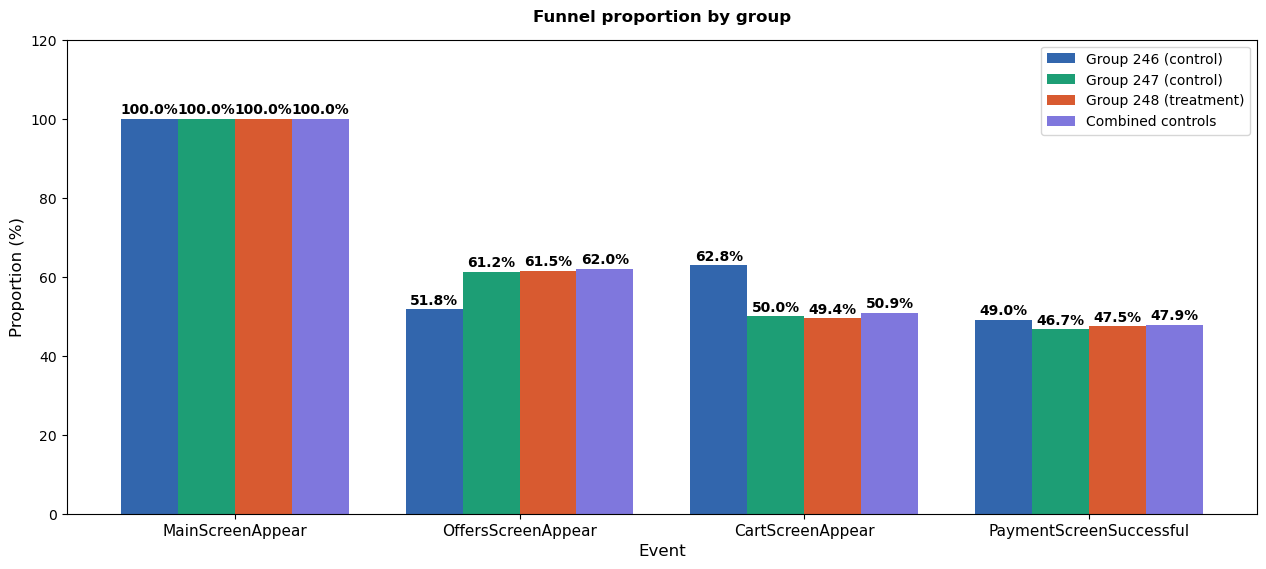

In [33]:
# Create a grouped bar chart to compare the funnel proportion across all groups.
fig, ax11 = plt.subplots(figsize=(14, 6))

funnel_steps = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']

prop_246 = top_246[top_246['event_name'].isin(funnel_steps)]['proportion'].tolist()
prop_247 = top_247[top_247['event_name'].isin(funnel_steps)]['proportion'].tolist()
prop_248 = top_248[top_248['event_name'].isin(funnel_steps)]['proportion'].tolist()
prop_combined = control_groups[control_groups['event_name'].isin(funnel_steps)]['proportion'].tolist()

x = np.arange(len(funnel_steps))
width = 0.2

bars_246 = ax11.bar(x - width*1.5, prop_246, width, label='Group 246 (control)', color='#3266ad')
bars_247 = ax11.bar(x - width*0.5, prop_247, width, label='Group 247 (control)', color='#1D9E75')
bars_248 = ax11.bar(x + width*0.5, prop_248, width, label='Group 248 (treatment)', color='#D85A30')
bars_combined = ax11.bar(x + width*1.5, prop_combined, width, label='Combined controls', color='#7F77DD')

for bars in [bars_246, bars_247, bars_248, bars_combined]:
    for bar in bars:
        height = bar.get_height()
        ax11.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{height:.1f}%',
                  ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

ax11.set_xticks(x)
ax11.set_xticklabels(funnel_steps, fontsize=11)
ax11.set_ylabel('Proportion (%)', fontsize=12)
ax11.set_xlabel('Event', fontsize=12)
ax11.set_title('Funnel proportion by group', fontweight='bold', fontsize=12, pad=13)
ax11.set_ylim(0, 120)
ax11.legend(fontsize=10)

plt.subplots_adjust(left=0.1, right=0.95, top=0.9, hspace=0.4)
plt.show()

Based on the current analysis, **no statistically significant differences** were found between groups. However, the **significance level** has not been formally defined yet. Once established, results will be re-evaluated to confirm these conclusions.

### Significance level corrected.

In [34]:
# All p-values from the z-tests (excluding MainScreenAppear and Tutorial)
p_values = [
    # 246 vs 247
    0.26223, 0.24012, 0.12044,
    # 246 vs 248
    0.26843, 0.10061, 0.25826,
    # 247 vs 248
    0.98694, 0.64082, 0.66992,
    # control_groups vs 248
    0.53086, 0.22405, 0.68631
]

comparisons = [
    ('246 vs 247', 'OffersScreenAppear'), ('246 vs 247', 'CartScreenAppear'), ('246 vs 247', 'PaymentScreenSuccessful'),
    ('246 vs 248', 'OffersScreenAppear'), ('246 vs 248', 'CartScreenAppear'), ('246 vs 248', 'PaymentScreenSuccessful'),
    ('247 vs 248', 'OffersScreenAppear'), ('247 vs 248', 'CartScreenAppear'), ('247 vs 248', 'PaymentScreenSuccessful'),
    ('Control vs 248', 'OffersScreenAppear'), ('Control vs 248', 'CartScreenAppear'), ('Control vs 248', 'PaymentScreenSuccessful'),
]

reject, p_corrected, _, _ = multipletests(p_values, alpha=0.05, method='holm')

for (comparison, event), p_orig, p_corr, rej in zip(comparisons, p_values, p_corrected, reject):
    print(f'{comparison} | {event}')
    print(f'  Original p-value: {p_orig:.5f} | Corrected p-value: {p_corr:.5f} | Reject H0: {rej}')

246 vs 247 | OffersScreenAppear
  Original p-value: 0.26223 | Corrected p-value: 1.00000 | Reject H0: False
246 vs 247 | CartScreenAppear
  Original p-value: 0.24012 | Corrected p-value: 1.00000 | Reject H0: False
246 vs 247 | PaymentScreenSuccessful
  Original p-value: 0.12044 | Corrected p-value: 1.00000 | Reject H0: False
246 vs 248 | OffersScreenAppear
  Original p-value: 0.26843 | Corrected p-value: 1.00000 | Reject H0: False
246 vs 248 | CartScreenAppear
  Original p-value: 0.10061 | Corrected p-value: 1.00000 | Reject H0: False
246 vs 248 | PaymentScreenSuccessful
  Original p-value: 0.25826 | Corrected p-value: 1.00000 | Reject H0: False
247 vs 248 | OffersScreenAppear
  Original p-value: 0.98694 | Corrected p-value: 1.00000 | Reject H0: False
247 vs 248 | CartScreenAppear
  Original p-value: 0.64082 | Corrected p-value: 1.00000 | Reject H0: False
247 vs 248 | PaymentScreenSuccessful
  Original p-value: 0.66992 | Corrected p-value: 1.00000 | Reject H0: False
Control vs 248 | Of

## Conclusion.

The **funnel analysis** shows that the **biggest drop-off** happens between **MainScreenAppear** and **OffersScreenAppear (~38.6%)**. After that, conversion stabilizes: **~49%** of users reach the cart and **~47%** complete payment.
The A/A/B test found **no statistically significant differences** between the control groups (246, 247) and the treatment group (248) at any funnel stage. After applying the Holm correction across 12 comparisons, all p-values adjusted to **1.0** — the null hypothesis was not rejected in any case.
The **font change in group 248** had no measurable effect on user behavior. If a follow-up experiment is considered, the MainScreen → Offers transition is the highest-leverage point to address, as it accounts for the largest user loss in the funnel